# The workbench

This notebook runs one synthetic activity through local production functions and configured cloud models. It generates the activity, draws its pages, adds synthetic handwriting, reads the returned page and asks for a continuation. Images, prompts, answers, errors and measured call durations stay in a new directory under `research/runs/`.

The household and handwriting are invented. The notebook does not contact a home, print paper, operate a scanner, change approval records or deploy code. Its author permits this synthetic run; that is not a parent's approval for a real household.

The declared minutes describe the document, not elapsed household time. This walk does not reproduce the hub clock, its help schedule or its end-hour calculation.

In [1]:
from __future__ import annotations

import importlib
import io
import json
import os
import sys
import time
from datetime import UTC, datetime
from pathlib import Path

from IPython.display import Image, display
from PIL import Image as Picture

START = Path.cwd().resolve()
ROOT = next(
    (candidate for candidate in (START, *START.parents)
     if (candidate / "pyproject.toml").is_file() and (candidate / "research").is_dir()),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Run this notebook inside the Lanternina repository")
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

bench = importlib.import_module("research.bench")

bench.environment()
FINGERPRINT = bench.reload_prompts()
RUN = ROOT / "research" / "runs" / datetime.now(UTC).strftime("%Y-%m-%d-officina-%H%M%S-%f")
print("prompt fingerprint:", FINGERPRINT)
print("synthetic artifacts:", RUN.relative_to(ROOT))

prompt fingerprint: 8035a0fd81c4
synthetic artifacts: research\runs\2026-09-07-officina-104746-339138


## The Calls

The hub requests an activity from the container. `panel.devising.devise_experience` chooses a method, generates the document, parses it, repairs an unreadable answer when needed, checks it, permits one separate repair of those checks and screens it with Content Safety. Persistent complaints stop the request. A failed method choice falls back to a random selection.

The hub later requests each page, reading and continuation from the container. The container invokes the writing, drawing and vision models. This notebook calls local functions directly; it does not verify the deployed HTTP service. `PageMaker` receives the page contract, not the script. `PageReader` returns `WhatCameBack`. `continue_experience` receives its `to_dict()` result, checks the new moments and screens them. It does not repair a rejected continuation.

The recorder prints each router prompt and response, including failed calls. It also records the separate image-edit call for synthetic handwriting. SDK retries inside a call are not separate entries. Content Safety is executed but is not counted as a router call. These records are not a billing ledger.

In [2]:
from research.households import Household, Memory, arguments

HOUSE = Household(
    name="synthetic-workbench", interests=("i treni", "le mappe vecchie"),
    avoid=("i ragni",), load="middle", ink="middle", span="middle", sheets=2, note="",
)
ARGS = arguments(HOUSE, Memory())
ARGS["brief"] = (
    "Una vecchia ferrovia ammette piu ricostruzioni del suo tracciato. "
    "Prepara due fogli complementari da leggere insieme: una mappa con osservazioni "
    "e un taccuino su cui disegnare o annotare una ricostruzione possibile. "
    "Consegna entrambi prima della prima raccolta. Le informazioni necessarie devono "
    "essere sui fogli, non soltanto nel copione. Lascia spazio a ipotesi alternative "
    "motivate. Dopo la raccolta usa ask per sviluppare quanto e stato aggiunto al "
    "taccuino, poi arriva a una chiusura. Tutto il materiale e sintetico."
)
print(json.dumps({key: value for key, value in ARGS.items() if isinstance(value, str)},
                 ensure_ascii=False, indent=2))

{
  "language": "Italian",
  "pitch": "two things that have to be put side by side before either makes sense, and one turn where what looked true stops being true\na sheet may ask for a few words as well as marks, and the space left for them should be small enough that filling it is obviously finishable\nwrite the standard weight at the middle of its window",
  "note": "",
  "happened": "",
  "counts": "{\"afternoonsRun\": 0, \"ranToTheEnd\": 0, \"endedEarly\": 0, \"stopped\": 0, \"sheetsWrittenOn\": 0, \"sheetsBlank\": 0}",
  "direction": "Ask for about what the last ones asked for. Nothing here says to move either way.",
  "ground": "",
  "brief": "Una vecchia ferrovia ammette piu ricostruzioni del suo tracciato. Prepara due fogli complementari da leggere insieme: una mappa con osservazioni e un taccuino su cui disegnare o annotare una ricostruzione possibile. Consegna entrambi prima della prima raccolta. Le informazioni necessarie devono essere sui fogli, non soltanto nel copione. L

## Local Branch Checks

The tests exercise a blank sheet, print failure, two available sheets, failed and degraded readings, a stop and the step limit. They replace model calls. The next cell removes inherited cloud settings from the test process.

The simulator uses `instead` and `if_no_page` after an injected print failure. The current hub implements `instead`, but `run_experience.py` does not consume `if_no_page`; its runner remains at the collection. This branch test verifies the simulator and contract, not the missing hub behavior.

In [3]:
import subprocess

test_environment = {
    key: value for key, value in os.environ.items()
    if not (key.startswith("LANTERNINA_") and
            any(part in key for part in ("FOUNDRY", "CONTENT_SAFETY", "SAFETY")))
}
began = time.perf_counter()
checked = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_workbench.py", "tests/test_handwriting.py", "-q"],
    env=test_environment, capture_output=True, text=True, encoding="utf-8",
)
print(checked.stdout)
print(checked.stderr)
print(f"elapsed: {time.perf_counter() - began:.1f} s")
checked.check_returncode()

..............                                                           [100%]
14 passed in 3.47s


elapsed: 5.2 s


## The Whole Activity

The image model receives the target sheet first and other available sheets as references. The reader compares the target's printed image with the returned image. Every collection names the sheet it reads.

A continuation replaces the active segment. As in the hub, the original approved experience is sent with a later request. This does not establish support for arbitrarily repeated continuations. Drawing, handwriting and reading failures report errors. A `close` moment produces `concluded`; the step limit or an explicit stop produces `interrupted`. Fallback events retain their status even when the walk later concludes.

The gate and recorder close in `finally`. Rerunning creates a new directory and reloads prompts before constructing agents.


--- SENT: choosing what to build an afternoon out of ---
You are about to devise one activity for one adolescent to spend at home. First you are choosing what to build it out of.

Below is a catalogue of methods that work on paper, filtered to the ones this house can actually run. Each line is an id and a name. Some are marked as a move: a move is not something to do on its own — it is applied to a form and changes what the form asks of somebody.

The parent wrote down these interests, as a place to begin: ["i treni", "le mappe vecchie"]
And these things to keep away from: ["i ragni"]
Activities already offered here: []
How the activity should be pitched: two things that have to be put side by side before either makes sense, and one turn where what looked true stops being true
a sheet may ask for a few words as well as marks, and the space left for them should be small enough that filling it is obviously finishable
write the standard weight at the middle of its window

Choose one form

--- RETURNED: choosing what to build an afternoon out of (17.889 s) ---


{"form":"what-changed-between-two-pictures","move":"one-fact-that-changes-what-was-already-read","why":"Two old railway maps make their differences legible together, until one new fact overturns the first interpretation."}



--- SENT: devising an afternoon ---
You are making one activity for one adolescent to spend at home, mostly on their own, in a house with a printer, a scanner and a small screen or two. Not a lesson, not a test, and not an exercise with a story painted over it. One thing worth doing, that happens once, and is over when it is over.

A parent glances at your overview before this happens, and may add something of their own. That is not a tribunal and you are not defending anything: they are seeing roughly what is coming, for somebody they know and you do not. Write the overview so that one glance says what this activity actually is. Nothing here is set in stone either — an activity can turn out differently once it has started, and that is ordinary rather than a failure.

An activity is a good one when these things are true of it.

Somebody can start it alone. The first screen puts a situation in front of them, they can see what to pick up, and no adult has to explain anything first.

The

--- RETURNED: devising an afternoon (118.146 s) ---


{"title":"La ferrovia ruotata","overview":"Confronta una carta ferroviaria con un taccuino, traccia un percorso possibile e annota un’alternativa. Dalla stampante escono una mappa con osservazioni e una pagina di taccuino per la ricostruzione. Alla fine restano la mappa segnata e il tracciato corretto. Non serve altro. Un fatto finale rende falsa l’orientazione usata all’inizio.","themes":["ferrovie dismesse","cartografia storica","tracciati alternativi","orientamento"],"script":"THE WORLD\nLa carta raffigura una ferrovia immaginaria, chiusa prima che il suo tracciato fosse registrato con precisione. Restano un casello, due filari, un ponte sul ruscello, uno stagno e una trincea tra due colline. Sono tutti elementi fittizi. Il copista della carta ha indicato il bordo alto come nord.\n\nTHE WAY IN\nLa stampante consegna prima la carta del tracciato. Chi la prende individua e cerchia il casello. Subito dopo arriva il taccuino della ricostruzione, da mettere accanto alla carta. Le due pag

[1] hand_over: La massicciata scompare



--- SENT: drawing a map ---
The page is a hand-drawn map, the kind folded into the back of an old book: a border, a coastline or paths, and small symbols for places.

Letter this large, as the title: "Il tracciato di Valle Lunga"
Letter this smaller, under the title: "Il copista scrisse: il bordo alto è nord. La linea univa il casello alla trincea, passando tra i filari. Attraversava il ruscello sul ponte; il lato dello stagno è incerto. Cerchia il casello. Poi usa questa carta insieme al taccuino."

What the drawing on the page shows: A clean overhead map of an invented valley. A small rectangular railway hut stands near the lower left. Two parallel rows of round-topped trees occupy the center-left. A winding stream crosses the middle with one simple arched bridge. An oval pond lies to the right of the bridge. Two rounded hills near the upper right leave a narrow gap between them. Pale broken traces suggest several possible curves but no complete railway line.
Drawn with an etching n

--- RETURNED: drawing a map (43.808 s) ---


<970264 bytes>


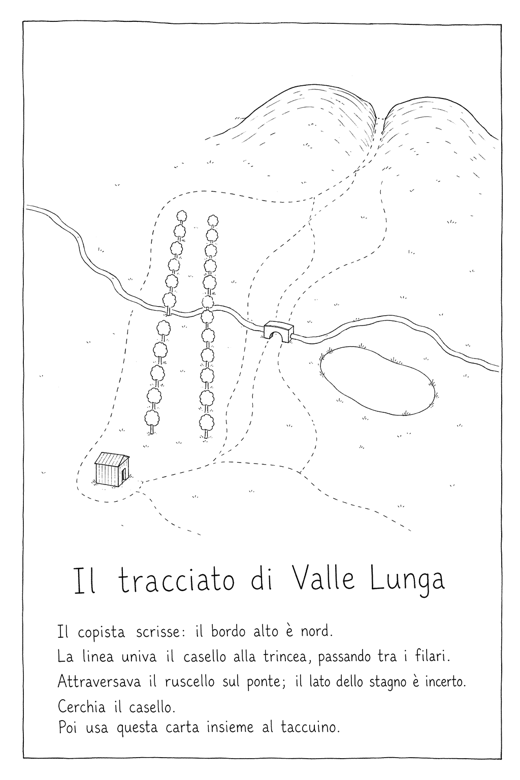

[2] hand_over: Una linea possibile



--- SENT: drawing a notebook ---
The page is a leaf out of a field notebook: a margin rule down the left and a quick sketch in one corner. Rule lines only where the page asks for something to be written, and leave the paper plain everywhere else.

Letter this large, as the title: "Ipotesi per Valle Lunga"
Letter this smaller, under the title: "Metti la carta accanto a questa pagina. Ricopia i luoghi e uniscili seguendo le osservazioni. Segna il lato dello stagno e la direzione data dal nord stampato. Una linea, due parole e un’alternativa completano l’ipotesi."
Leave an empty box about a third of the page high, to draw in, with "Tracciato possibile" lettered above it
Leave one ruled line, long enough for a few words, with "Lo stagno resta a" lettered above it
Leave one ruled line, long enough for a few words, with "Direzione generale" lettered above it
Leave one ruled line, long enough for a few words, with "Altra linea possibile" lettered above it

What the drawing on the page shows:

--- RETURNED: drawing a notebook (26.25 s) ---


<638280 bytes>


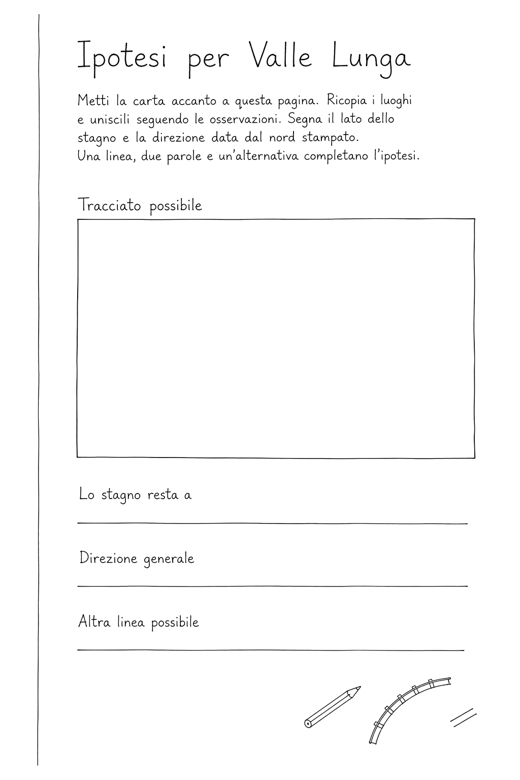

[3] collect: La carta viene riletta



--- SENT: synthetic handwriting ---
The same sheet of paper, now filled in by a teenager with a blue ballpoint pen: untidy, slanted, not always on the line, a word crossed out somewhere.
Answer what the page asks, in Italian, briefly and in your own words — the way somebody of thirteen would, not the way a form would. Where there is a box to draw in, draw something rough.
Change nothing that is already printed on the page: not the title, not the lines, not the drawing. Add only what a person would have added, and leave the paper the same size.
Write only on the FIRST image. The other 1 images are sheets already on the table. Use their content when the first sheet refers to them. Return only the first sheet, with the added handwriting.


--- RETURNED: synthetic handwriting (40.015 s) ---


<716690 bytes>


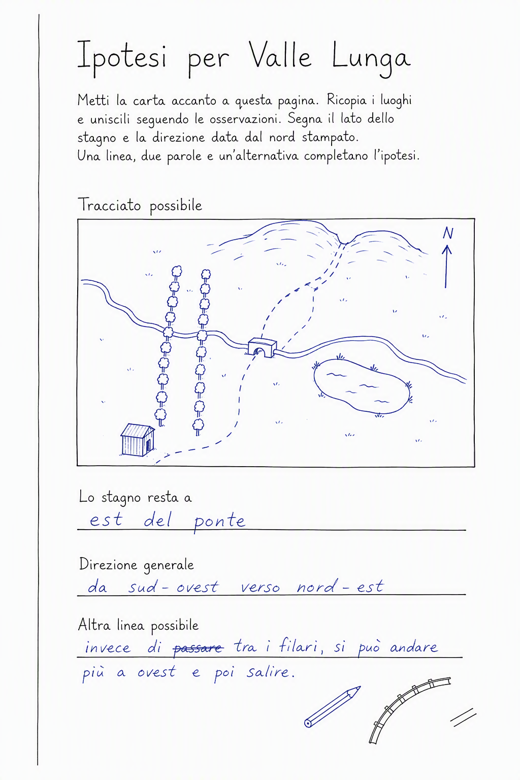


--- SENT: reading a page against its blank ---
Two images of the same kind of sheet of paper. The first is the sheet as it was printed, with nothing written on it. The second is the sheet after somebody had it.
Say what is on the second that is not on the first.
Answer with JSON and nothing else, in this exact shape:
{"written": true, "same_sheet": true, "describes": ["...", "..."]}
"written" is true if anything at all was added: a line, a word, a drawing, a tick, a scribble. False if the second sheet carries nothing the first did not.
"same_sheet" is true if the second image is the first sheet, written on. False if it is a different sheet altogether. Say false plainly; it is not a complaint.
"describes" is what was added, one short phrase each, at most 8 of them and at most 120 characters each. Describe the ink on the paper and where it sits: 'a house drawn in the box on the left', 'three words on the first line', 'the second box left untouched'.
Two things you must not do. Do not sa

--- RETURNED: reading a page against its blank (9.599 s) ---


{"written":true,"same_sheet":true,"describes":["blue landscape drawn in the large box: hills, river, bridge, pond, trees and a hut","a dashed blue route drawn from the lower left through the bridge toward the hills","a blue north arrow marked “N” in the upper-right of the box","“est del ponte” written on the first answer line","“da sud-ovest verso nord-est” written on the second answer line","“invece di passare tra i filari, si può andare più a ovest e poi salire.” on the last lines","the word “passare” in the last response is crossed out"]}



--- SENT: continuing aftn-167d1874 after read-scan ---
You are writing the rest of an activity in one household. It was planned this far and the plan says the rest depends on what came back on paper.
Answer with JSON and nothing else, in this exact shape:
{"moments": [ ... ]}
Which activity this is and which moment it follows are known already and are not yours to write.
Every moment, whatever it does, carries these five keys and then whatever its act adds:
  "id": 2 to 32 characters of lowercase a-z, digits and hyphens. No capitals, no accented letters, no underscores and no spaces. Ids are never shown to anybody, so write them in English even when the activity is not.
  "heading": at most 28 characters, on the display.
  "weights": {"short": W, "standard": W, "extended": W} — the same moment at three costs, reaching the same point in the story. W is {"minutes": <whole number>, "lines": [a list of at most 4 lines, each at most 44 characters]}. The short one takes about a third of the

--- RETURNED: continuing aftn-167d1874 after read-scan (74.784 s) ---


...

[5] close: Il tracciato ruotato



--- SENT: reading a page against its blank ---
Two images of the same kind of sheet of paper. The first is the sheet as it was printed, with nothing written on it. The second is the sheet after somebody had it.
Say what is on the second that is not on the first.
Answer with JSON and nothing else, in this exact shape:
{"written": true, "same_sheet": true, "describes": ["...", "..."]}
"written" is true if anything at all was added: a line, a word, a drawing, a tick, a scribble. False if the second sheet carries nothing the first did not.
"same_sheet" is true if the second image is the first sheet, written on. False if it is a different sheet altogether. Say false plainly; it is not a complaint.
"describes" is what was added, one short phrase each, at most 8 of them and at most 120 characters each. Describe the ink on the paper and where it sits: 'a house drawn in the box on the left', 'three words on the first line', 'the second box left untouched'.
Two things you must not do. Do not sa

--- RETURNED: reading a page against its blank (2.067 s) ---


{"written":false,"same_sheet":true,"describes":[]}


{
  "status": "concluded",
  "reason": "",
  "built_from": {
    "form": "what-changed-between-two-pictures",
    "move": "one-fact-that-changes-what-was-already-read"
  },
  "blank_reading": {
    "written": false,
    "same_sheet": true,
    "describes": [],
    "read_at": 1788778072.1684253,
    "degraded": false,
    "metadata": {
      "read_by": "page_reader",
      "request_id": "rq_f249720b",
      "latency_s": 2.07
    }
  },
  "reading_in_continuation_prompt": true,
  "continuations": 1,
  "seconds": 335.597
}
concluded 
195.5 s measured; 63 document minutes


In [4]:
from research.workbench import live_activity


def seen(png: bytes) -> None:
    with Picture.open(io.BytesIO(png)) as picture:
        picture.thumbnail((520, 780))
        preview = io.BytesIO()
        picture.save(preview, format="PNG")
    display(Image(data=preview.getvalue()))


RESULT = await live_activity(RUN, ARGS, show=seen)
print(RESULT.status, RESULT.reason)
print(f"{RESULT.seconds:.1f} s measured; {RESULT.declared_minutes} document minutes")

## Verification

The run passes only when it concludes, retains at least two drawn sheets, makes a continuation whose actual prompt contains the returned descriptions, and reads an untouched sheet as blank. These checks verify the model path. They do not prove that a person understands or enjoys the activity. Inspect the full-size images and script; automatic judges can report false positives.

In [5]:
VERIFICATION = json.loads((RUN / "verification.json").read_text(encoding="utf-8"))
assert RESULT.status == "concluded", RESULT.reason
assert len(RESULT.pages) >= 2, "This run did not exercise two sheets"
assert VERIFICATION["continuations"] >= 1, "No continuation was requested"
assert VERIFICATION["reading_in_continuation_prompt"], "The reading was absent from the prompt"
assert not VERIFICATION["blank_reading"]["written"], "The untouched page was read as marked"
assert not VERIFICATION["blank_reading"]["degraded"], "The blank-page reading failed"
assert not any(event.get("status") == "fallback" for event in RESULT.events)
print("PASS: synthetic activity, two sheets, reading, continuation and blank-page control")

PASS: synthetic activity, two sheets, reading, continuation and blank-page control


## The Record

Synthetic research deliberately retains material that production keeps ephemeral. Do not use real household data or handwriting here. `calls.json` contains successful and failed calls; `walk.json` separates states and names images. `verification.json` stores measurements and checks. A generation exception leaves `error.json`.

Prompt changes require `python -m tools.prompts --write` and isolated software tests. The historical eight-axis appraisal has transcript and closed-task limitations described in `ideas/13-prompts-and-simulation.md`; its counts do not demonstrate quality here.

In [6]:
CALLS = json.loads((RUN / "calls.json").read_text(encoding="utf-8"))
for index, call in enumerate(CALLS, 1):
    print(f"{index:2} {call['seconds']:7.1f} s {call['status']:6} {call['purpose']}")
print("Artifacts:", RUN.relative_to(ROOT))
print("Physical checks remain: printed legibility, paper handling, scan and comprehension.")

 1    17.9 s ok     choosing what to build an afternoon out of
 2   118.1 s ok     devising an afternoon
 3    43.8 s ok     drawing a map
 4    26.2 s ok     drawing a notebook
 5    40.0 s ok     synthetic handwriting
 6     9.6 s ok     reading a page against its blank
 7    74.8 s ok     continuing aftn-167d1874 after read-scan
 8     2.1 s ok     reading a page against its blank
Artifacts: research\runs\2026-09-07-officina-104746-339138
Physical checks remain: printed legibility, paper handling, scan and comprehension.
